# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

- Read CSV

In [2]:
df = pd.read_csv('insurance.csv')

- shape attribute

In [3]:
df.shape

(1338, 7)

- head()

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


- df.info()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


- describe

In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


- Check if there are any null valus

In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

- find info about the columns in the data

In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

- Extract the numerical values

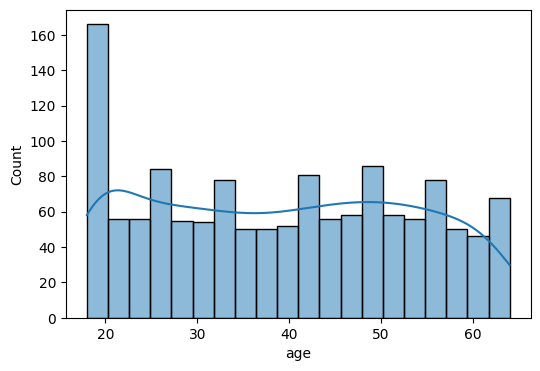

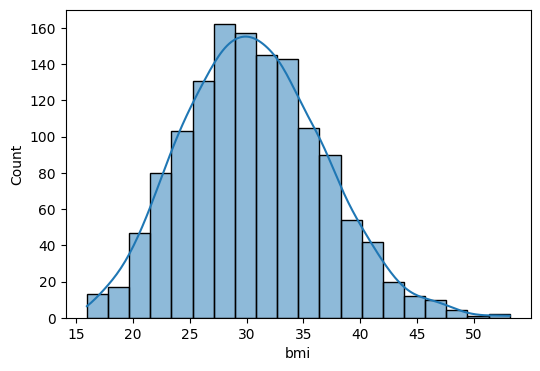

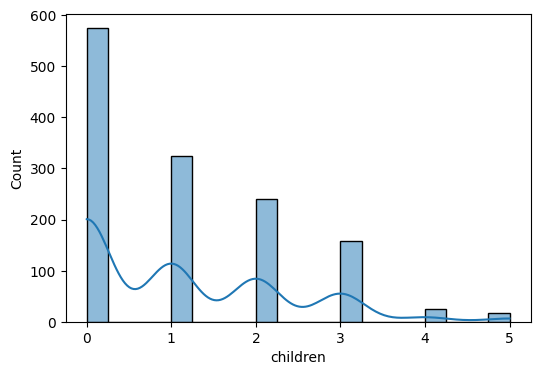

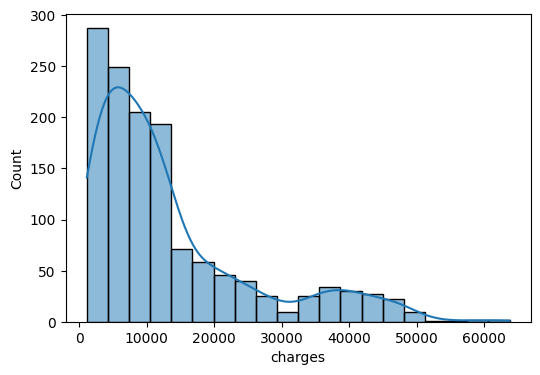

In [9]:
numeric_columns = ['age', 'bmi', 'children', 'charges']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde = True, bins = 20)

- Count Plot for Categorical Columns

<Axes: xlabel='children', ylabel='count'>

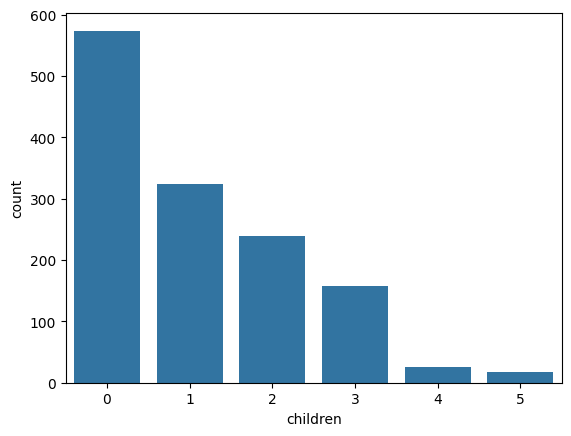

In [10]:
sns.countplot(x =df['children'])

<Axes: xlabel='sex', ylabel='count'>

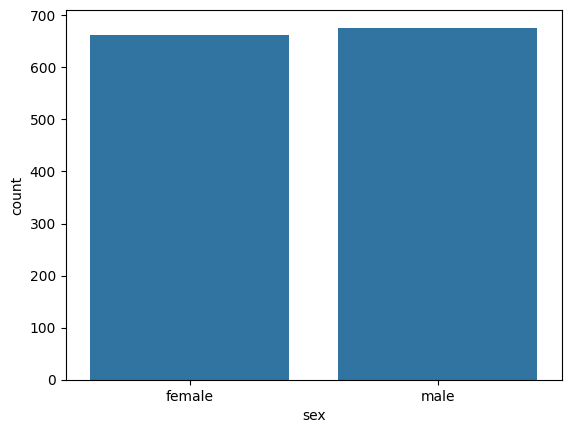

In [11]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

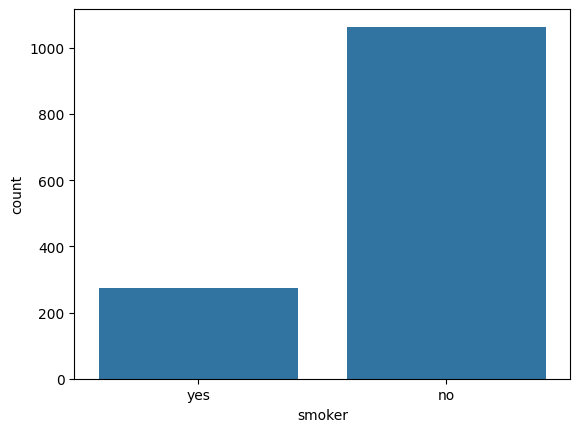

In [12]:
sns.countplot(x = df['smoker'])

- Box Plot for Numerical data to find outliers

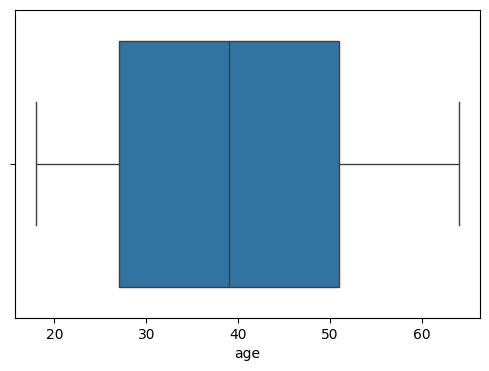

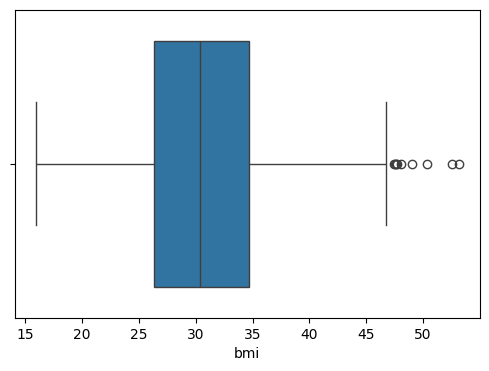

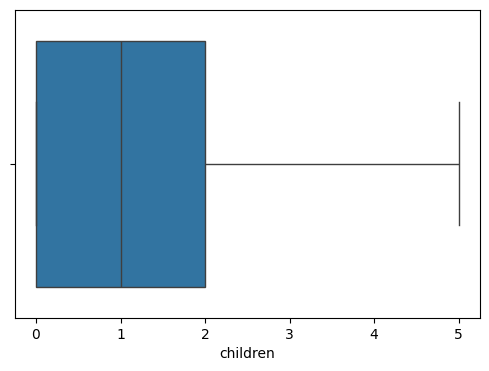

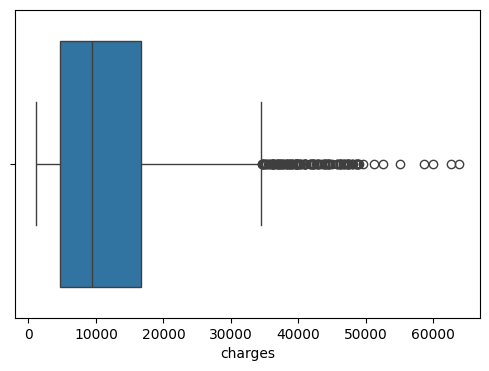

In [13]:
for col in numeric_columns:
    plt.figure(figsize= (6,4))
    sns.boxplot( x = df[col])

- Let's find Correlation between Columns

<Axes: >

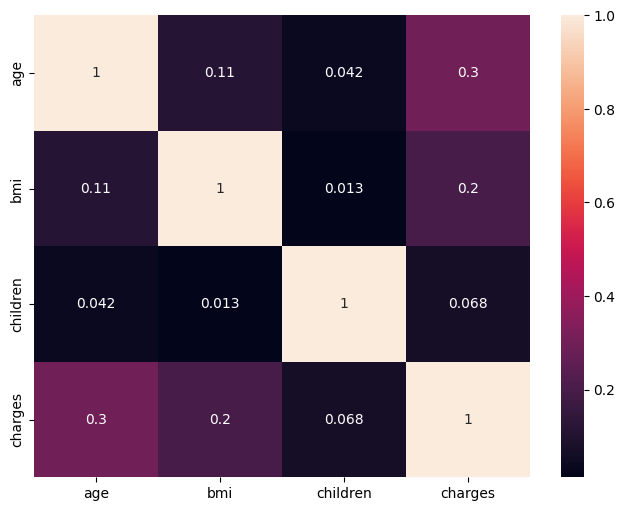

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only = True), annot = True)

- Data Cleaning and preprocessing

In [15]:
df_clean = df.copy()
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [16]:
df_clean.drop_duplicates(inplace = True)

In [17]:
df_clean.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [18]:
df_clean.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [19]:
df_clean['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

- Label Encoding

In [20]:
df_clean['sex'] = df_clean['sex'].map({'male': 0 , 'female': 1})

In [21]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [22]:
df_clean['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [23]:
df_clean['smoker'] = df_clean['smoker'].map({'yes': 1, 'no': 0 })

In [24]:
df_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


- Rename Column Names

In [25]:
df_clean.rename(columns= {
    'sex': 'is_female',
    'smoker': 'is_smoker'
}, inplace= True)

In [26]:
df_clean.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


- One-Hot Encoding

In [27]:
df_clean['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [28]:
df_clean = pd.get_dummies(df_clean, columns = ['region'], drop_first= True)

In [29]:
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [30]:
df_clean = df_clean.astype(int)

In [31]:
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


# Feature Engineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

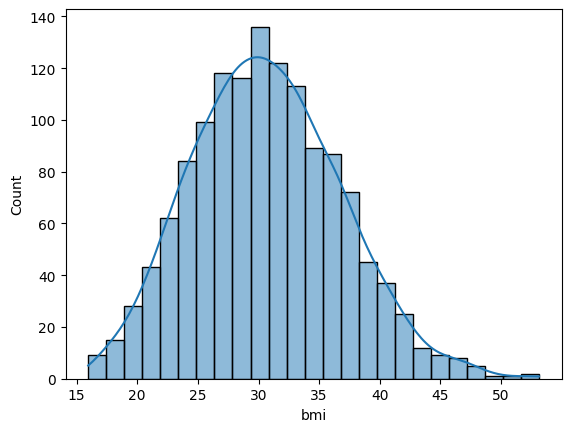

In [32]:
sns.histplot( x = df['bmi'], kde = True)

In [33]:
df_clean['bmi_category'] = pd.cut(
    df_clean['bmi'],
    bins = [0, 18.5, 24.4, 29.4, float('inf') ],
    labels= ['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [34]:
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight


In [35]:
df_clean = pd.get_dummies(
    df_clean, columns= ['bmi_category'] , drop_first = True
)

In [36]:
df_clean.tail()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
1333,50,0,30,3,0,10600,1,0,0,False,False,True
1334,18,1,31,0,0,2205,0,0,0,False,False,True
1335,18,1,36,0,0,1629,0,1,0,False,False,True
1336,21,1,25,0,0,2007,0,0,1,False,True,False
1337,61,1,29,0,1,29141,1,0,0,False,True,False


In [37]:
df_clean.astype(int)

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


- Applying Standard Scaler

In [38]:
from sklearn.preprocessing import StandardScaler
cols = ['age', 'bmi', 'children']
scaler  = StandardScaler()

df_clean[col] = scaler.fit_transform(df_clean[cols])

In [39]:
df_clean.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,-1.440418,0,0,1,False,True,False
1,18,0,33,1,0,-1.511647,0,1,0,False,False,True
2,28,0,33,3,0,-0.799350,0,1,0,False,False,True
3,33,0,22,0,0,-0.443201,1,0,0,True,False,False
4,32,0,28,0,0,-0.514431,1,0,0,False,True,False


# Feature Extraction

In [40]:
from scipy.stats import pearsonr

# ----------------------------------
# Pearson Correlation Calculation
# ----------------------------------

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

correlations = {
    feature: pearsonr(df_clean[feature], df_clean['charges'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
0,age,1.000000
1,bmi,0.108491
10,bmi_category_Obese,0.086781
2,children,0.041536
3,is_female,0.019814
7,region_southwest,0.009415
5,region_northwest,0.001495
6,region_southeast,-0.012311
9,bmi_category_Overweight,-0.013608
4,is_smoker,-0.025587


In [41]:
cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

In [42]:

from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_clean['charges_bin'] = pd.qcut(df_clean['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_clean[col], df_clean['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
bmi_category_Obese,14.484873,0.002314,Reject Null (Keep Feature)
bmi_category_Normal,6.546313,0.087854,Accept Null (Drop Feature)
bmi_category_Overweight,6.073155,0.108105,Accept Null (Drop Feature)
is_smoker,2.021106,0.568038,Accept Null (Drop Feature)
is_female,0.472488,0.924893,Accept Null (Drop Feature)
region_southeast,0.464118,0.926701,Accept Null (Drop Feature)
region_northwest,0.173039,0.98182,Accept Null (Drop Feature)
region_southwest,0.121237,0.989172,Accept Null (Drop Feature)


In [43]:
final_df = df_clean[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges','region_southeast','bmi_category_Obese']]

In [44]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese
0,19,1,27,0,1,-1.440418,0,False
1,18,0,33,1,0,-1.511647,1,True
2,28,0,33,3,0,-0.799350,1,True
3,33,0,22,0,0,-0.443201,0,False
4,32,0,28,0,0,-0.514431,0,False
...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,0.767704,0,True
1334,18,1,31,0,0,-1.511647,0,True
1335,18,1,36,0,0,-1.511647,1,True
1336,21,1,25,0,0,-1.297958,0,False


In [45]:
final_df.to_csv('output.csv', index=False)